# Confronto Metriche di Validazione — Due Modelli

Questo notebook scarica da Google Drive i file `val_metrics.json` di due esperimenti e produce un confronto visivo e tabellare delle metriche sul validation set.

In [1]:
import os
import sys

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
else:
    print("Ambiente locale rilevato.")
    BASE_PATH = '../'

print(f"Percorso base: {BASE_PATH}")

Ambiente locale rilevato.
Percorso base: ../


#### Import

In [2]:
import json
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import seaborn as sns
from pathlib import Path

#### Configurazione

Inserisci gli ID Google Drive dei due file `val_metrics.json` e le etichette da mostrare nei grafici.

In [3]:
MODEL_A = {
    "drive_id": "172qRzuRKsQF7MO34bJLlF6AX7JHc13i6",
    "label": "ResNet-50",                    
    "color": "#2196F3",
}

MODEL_B = {
    "drive_id": "1oC9KV9TGzPhm98YPQZ2slTX0vh4a6h_d",
    "label": "EfficientNetB3",
    "color": "#FF5722",
}

OUTPUT_DIR = os.path.join(BASE_PATH, 'results', 'confronto_metriche_val_classificatori')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"Cartella output: {OUTPUT_DIR}")
print(f"Cartella figure: {FIGURES_DIR}")

Cartella output: ../results/confronto_metriche_val_classificatori
Cartella figure: ../results/confronto_metriche_val_classificatori/figures


#### Download metriche da Google Drive

In [22]:
def download_metrics(config: dict, dest_dir: str) -> dict:
    """Scarica val_metrics.json da Google Drive e lo restituisce come dict."""
    dest_path = os.path.join(dest_dir, f"val_metrics_{config['label'].replace(' ', '_')}.json")
    
    if not os.path.isfile(dest_path):
        print(f"Scarico metriche per '{config['label']}' da Google Drive...")
        gdown.download(id=config["drive_id"], output=dest_path, quiet=False)
    else:
        print(f"File già presente per '{config['label']}', salto il download.")
    
    with open(dest_path, 'r', encoding='utf-8') as f:
        return json.load(f)


metrics_a = download_metrics(MODEL_A, OUTPUT_DIR)
metrics_b = download_metrics(MODEL_B, OUTPUT_DIR)

print("\nMetriche caricate con successo.")

File già presente per 'ResNet-50', salto il download.
File già presente per 'EfficientNetB3', salto il download.

Metriche caricate con successo.


#### Tabella di confronto

In [23]:
METRIC_KEYS = [
    ("auc",                "AUC"),
    ("accuracy",           "Accuracy"),
    ("precision_cancer",   "Precision (Cancro)"),
    ("recall_cancer",      "Recall (Cancro)"),
    ("f1_cancer",          "F1 (Cancro)"),
    ("optimal_threshold_youden", "Soglia ottimale (Youden)"),
]

rows = []
for key, label in METRIC_KEYS:
    val_a = metrics_a.get(key, "N/A")
    val_b = metrics_b.get(key, "N/A")
    delta = round(val_a - val_b, 4) if isinstance(val_a, (int, float)) and isinstance(val_b, (int, float)) else "N/A"
    rows.append({
        "Metrica": label,
        MODEL_A["label"]: val_a,
        MODEL_B["label"]: val_b,
        f"Delta ({MODEL_A['label']} - {MODEL_B['label']})": delta,
    })

df_compare = pd.DataFrame(rows)
df_compare = df_compare.set_index("Metrica")

# Stile: evidenzia il valore migliore (più alto) tra i due modelli per le metriche principali
highlight_keys = {"AUC", "Accuracy", "Precision (Cancro)", "Recall (Cancro)", "F1 (Cancro)"}

def highlight_best(row):
    if row.name not in highlight_keys:
        return [""] * len(row)
    try:
        a, b = float(row[MODEL_A["label"]]), float(row[MODEL_B["label"]])
        if a > b:
            return ["background-color: #d4edda", "background-color: #fff3cd", ""]
        elif b > a:
            return ["background-color: #fff3cd", "background-color: #d4edda", ""]
        else:
            return ["", "", ""]
    except (ValueError, TypeError):
        return [""] * len(row)

display(df_compare.style.apply(highlight_best, axis=1).format(precision=4))

,ResNet-50,EfficientNetB3,Delta (ResNet-50 - EfficientNetB3)
Metrica,,,
AUC,0.6724,0.6467,0.0257
Accuracy,0.5606,0.4027,0.1579
Precision (Cancro),0.2468,0.2117,0.0351
Recall (Cancro),0.7945,0.9452,-0.1507
F1 (Cancro),0.3766,0.3459,0.0307
Soglia ottimale (Youden),0.2968,0.4729,-0.1761


#### Grafici di confronto

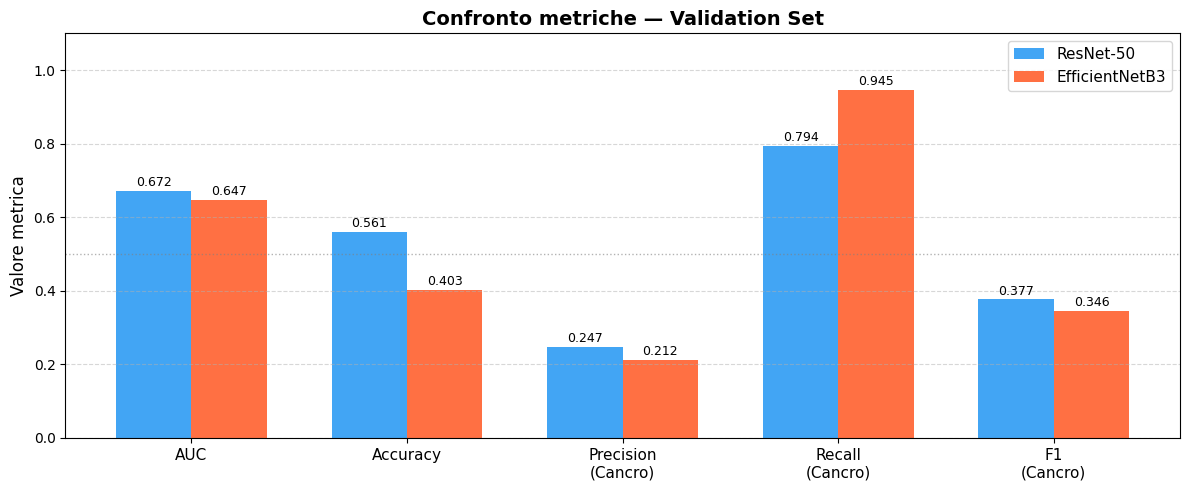

Grafico salvato in: ../results/confronto_metriche_val_classificatori/figures/confronto_metriche_barplot.png


In [24]:
PLOT_METRICS = [
    ("auc",              "AUC"),
    ("accuracy",         "Accuracy"),
    ("precision_cancer", "Precision\n(Cancro)"),
    ("recall_cancer",    "Recall\n(Cancro)"),
    ("f1_cancer",        "F1\n(Cancro)"),
]

keys   = [k for k, _ in PLOT_METRICS]
labels = [l for _, l in PLOT_METRICS]
vals_a = [metrics_a.get(k, 0) for k in keys]
vals_b = [metrics_b.get(k, 0) for k in keys]

x = np.arange(len(keys))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_a = ax.bar(x - width / 2, vals_a, width, label=MODEL_A["label"], color=MODEL_A["color"], alpha=0.85)
bars_b = ax.bar(x + width / 2, vals_b, width, label=MODEL_B["label"], color=MODEL_B["color"], alpha=0.85)

for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Valore metrica", fontsize=12)
ax.set_title("Confronto metriche — Validation Set", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.6)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'confronto_metriche_barplot.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grafico salvato in: {fig_path}")

#### Radar chart (Spider plot)

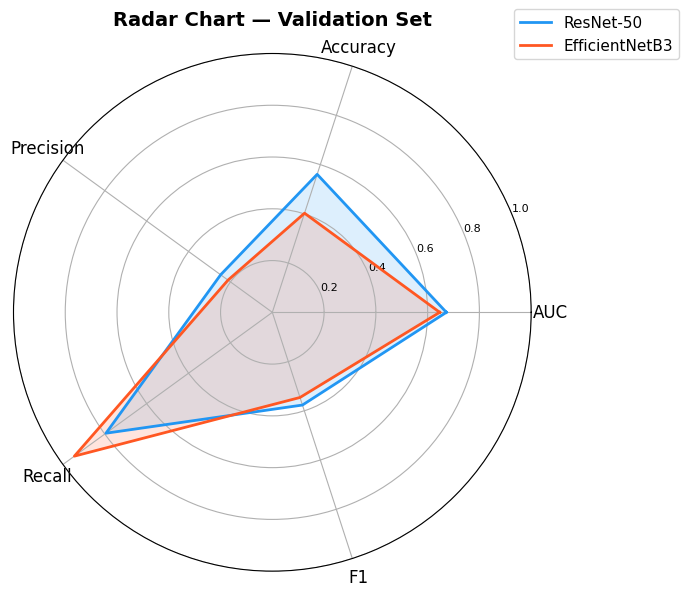

Radar chart salvato in: ../results/confronto_metriche_val_classificatori/figures/confronto_metriche_radar.png


In [25]:
RADAR_METRICS = [
    ("auc",              "AUC"),
    ("accuracy",         "Accuracy"),
    ("precision_cancer", "Precision"),
    ("recall_cancer",    "Recall"),
    ("f1_cancer",        "F1"),
]

r_keys  = [k for k, _ in RADAR_METRICS]
r_labels = [l for _, l in RADAR_METRICS]
N = len(r_labels)

vals_a_r = [metrics_a.get(k, 0) for k in r_keys]
vals_b_r = [metrics_b.get(k, 0) for k in r_keys]

# Chiudi il cerchio
vals_a_r += vals_a_r[:1]
vals_b_r += vals_b_r[:1]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, vals_a_r, color=MODEL_A["color"], linewidth=2, label=MODEL_A["label"])
ax.fill(angles, vals_a_r, color=MODEL_A["color"], alpha=0.15)

ax.plot(angles, vals_b_r, color=MODEL_B["color"], linewidth=2, label=MODEL_B["label"])
ax.fill(angles, vals_b_r, color=MODEL_B["color"], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(r_labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
ax.set_title("Radar Chart — Validation Set", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
radar_path = os.path.join(FIGURES_DIR, 'confronto_metriche_radar.png')
fig.savefig(radar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Radar chart salvato in: {radar_path}")

#### Classification Report completo

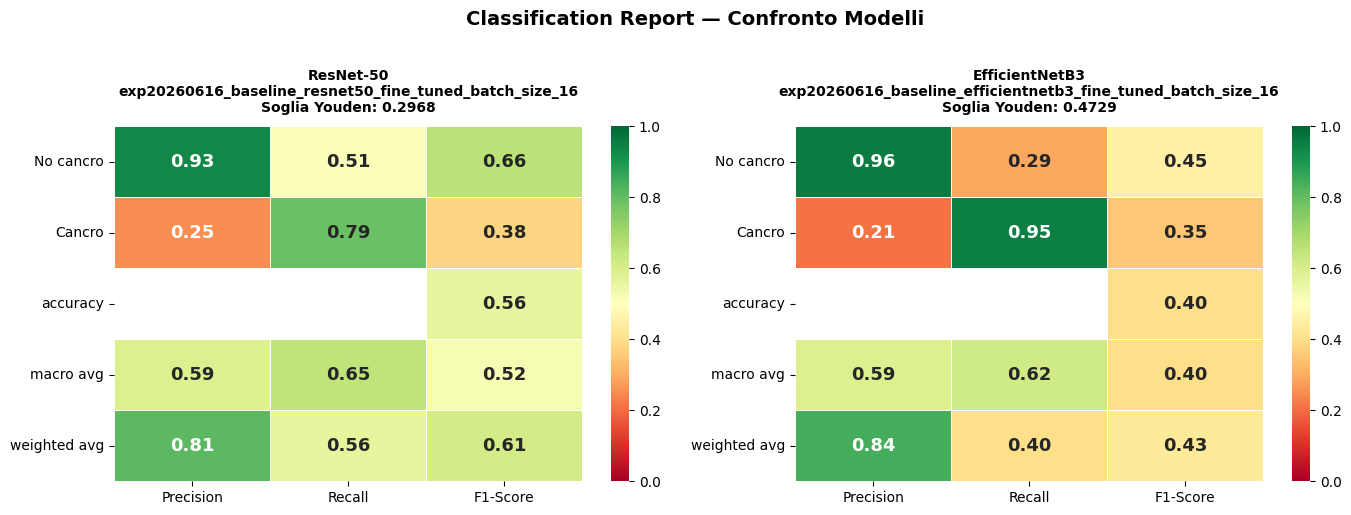

Heatmap salvata in: ../results/confronto_metriche_val_classificatori/figures/classification_report_heatmap.png


In [26]:
def parse_classification_report(report_str):
    lines = report_str.strip().split('\n')
    rows = []
    for line in lines:
        m = re.match(r'^\s*(.+?)\s{2,}(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s*$', line)
        if m:
            rows.append({
                'Classe': m.group(1).strip(),
                'Precision': float(m.group(2)),
                'Recall': float(m.group(3)),
                'F1-Score': float(m.group(4)),
                'Support': int(m.group(5)),
            })
        else:
            m2 = re.match(r'^\s*accuracy\s+(\d+\.\d+)\s+(\d+)\s*$', line)
            if m2:
                rows.append({
                    'Classe': 'accuracy',
                    'Precision': float('nan'),
                    'Recall': float('nan'),
                    'F1-Score': float(m2.group(1)),
                    'Support': int(m2.group(2)),
                })
    return pd.DataFrame(rows).set_index('Classe')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cfg, metrics) in zip(axes, [(MODEL_A, metrics_a), (MODEL_B, metrics_b)]):
    df = parse_classification_report(metrics.get("classification_report", ""))
    plot_df = df[['Precision', 'Recall', 'F1-Score']]

    # Annotazioni custom: celle NaN mostrate come stringa vuota
    annot = plot_df.copy().astype(object)
    for col in plot_df.columns:
        for idx in plot_df.index:
            v = plot_df.loc[idx, col]
            annot.loc[idx, col] = f'{v:.2f}' if not pd.isna(v) else ''

    sns.heatmap(
        plot_df,
        annot=annot,
        fmt='',
        cmap='RdYlGn',
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        cbar=True,
        annot_kws={"size": 13, "weight": "bold"},
    )

    threshold = metrics.get('optimal_threshold_youden', 'N/A')
    thresh_str = f'{threshold:.4f}' if isinstance(threshold, float) else threshold
    ax.set_title(
        f"{cfg['label']}\n{metrics.get('experiment_name', 'N/A')}\nSoglia Youden: {thresh_str}",
        fontsize=10, fontweight='bold', pad=10,
    )
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Classification Report — Confronto Modelli', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
report_path = os.path.join(FIGURES_DIR, 'classification_report_heatmap.png')
fig.savefig(report_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Heatmap salvata in: {report_path}")

#### Riepilogo testuale

In [ ]:
winner_map = {}
for key, label in METRIC_KEYS[:5]:  # solo le 5 metriche principali
    a, b = metrics_a.get(key), metrics_b.get(key)
    if isinstance(a, float) and isinstance(b, float):
        if a > b:
            winner_map[label] = MODEL_A["label"]
        elif b > a:
            winner_map[label] = MODEL_B["label"]
        else:
            winner_map[label] = "Pari"

print("Vincitore per metrica:")
for metric, winner in winner_map.items():
    print(f"  {metric:30s} → {winner}")

wins_a = sum(1 for w in winner_map.values() if w == MODEL_A["label"])
wins_b = sum(1 for w in winner_map.values() if w == MODEL_B["label"])
print(f"\nVittorie totali: {MODEL_A['label']} = {wins_a} | {MODEL_B['label']} = {wins_b}")

Vincitore per metrica:
  AUC                            → ResNet-50
  Accuracy                       → ResNet-50
  Precision (Cancro)             → ResNet-50
  Recall (Cancro)                → EfficientNetB3
  F1 (Cancro)                    → ResNet-50

Vittorie totali: ResNet-50 = 4 | EfficientNetB3 = 1


---
#### Log di Training — Fase 1 (Custom Head) e Fase 2 (Fine-Tuning)

In [4]:
# ── ID Google Drive dei log di training ──────────────────────────────────────
MODEL_A["log_fase1_id"] = "1FOJXIwaJo8VRrdYXcEbF7_FEr4k4oMs6"   # training_log_fase1.csv  ResNet-50
MODEL_A["log_fase2_id"] = "1z3jML-0JJM_7nTSfkO46O41PulLz1066"   # training_log_fase2.csv  ResNet-50
MODEL_B["log_fase1_id"] = "1_02za2FOo_JoSJ-Ad7kUNUCjPOMniXYZ"   # training_log_fase1.csv  EfficientNetB3
MODEL_B["log_fase2_id"] = "1qbJ_d02M8n8HyZFYnKOXFM57Ry7vpOCA"   # training_log_fase2.csv  EfficientNetB3

TRAINING_LOG_DIR = os.path.join(OUTPUT_DIR, "training_log")
os.makedirs(TRAINING_LOG_DIR, exist_ok=True)
print(f"Cartella log di training: {TRAINING_LOG_DIR}")

Cartella log di training: ../results/confronto_metriche_val_classificatori/training_log


In [5]:
def download_log(config: dict, fase: int, dest_dir: str) -> pd.DataFrame:
    """Scarica training_log_faseN.csv da Google Drive e lo restituisce come DataFrame."""
    drive_id = config[f"log_fase{fase}_id"]
    label = config["label"].replace(" ", "_")
    dest_path = os.path.join(dest_dir, f"training_log_fase{fase}_{label}.csv")

    if not os.path.isfile(dest_path):
        print(f"Scarico log fase {fase} per '{config['label']}'...")
        gdown.download(id=drive_id, output=dest_path, quiet=False)
    else:
        print(f"Log fase {fase} per '{config['label']}' già presente, salto il download.")

    return pd.read_csv(dest_path)


log_a1 = download_log(MODEL_A, 1, TRAINING_LOG_DIR)
log_a2 = download_log(MODEL_A, 2, TRAINING_LOG_DIR)
log_b1 = download_log(MODEL_B, 1, TRAINING_LOG_DIR)
log_b2 = download_log(MODEL_B, 2, TRAINING_LOG_DIR)

print("\nLog di training caricati con successo.")

Scarico log fase 1 per 'ResNet-50'...


Downloading...
From: https://drive.google.com/uc?id=1FOJXIwaJo8VRrdYXcEbF7_FEr4k4oMs6
To: /home/enzo/DeepLearning/MammoDiffusion/results/confronto_metriche_val_classificatori/training_log/training_log_fase1_ResNet-50.csv
100%|██████████| 3.00k/3.00k [00:00<00:00, 4.91MB/s]


Scarico log fase 2 per 'ResNet-50'...


Downloading...
From: https://drive.google.com/uc?id=1z3jML-0JJM_7nTSfkO46O41PulLz1066
To: /home/enzo/DeepLearning/MammoDiffusion/results/confronto_metriche_val_classificatori/training_log/training_log_fase2_ResNet-50.csv
100%|██████████| 1.40k/1.40k [00:00<00:00, 4.70MB/s]


Scarico log fase 1 per 'EfficientNetB3'...


Downloading...
From: https://drive.google.com/uc?id=1_02za2FOo_JoSJ-Ad7kUNUCjPOMniXYZ
To: /home/enzo/DeepLearning/MammoDiffusion/results/confronto_metriche_val_classificatori/training_log/training_log_fase1_EfficientNetB3.csv
100%|██████████| 2.02k/2.02k [00:00<00:00, 6.29MB/s]


Scarico log fase 2 per 'EfficientNetB3'...


Downloading...
From: https://drive.google.com/uc?id=1qbJ_d02M8n8HyZFYnKOXFM57Ry7vpOCA
To: /home/enzo/DeepLearning/MammoDiffusion/results/confronto_metriche_val_classificatori/training_log/training_log_fase2_EfficientNetB3.csv
100%|██████████| 1.43k/1.43k [00:00<00:00, 1.78MB/s]


Log di training caricati con successo.


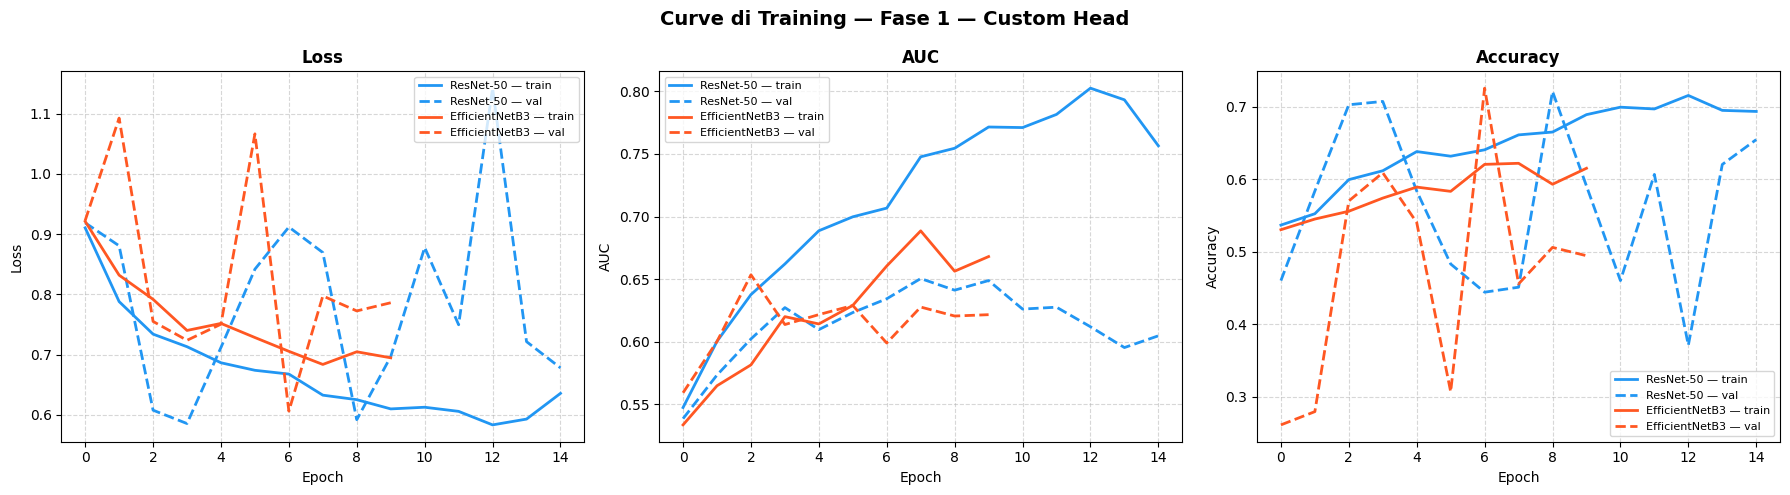

Grafico fase 1 salvato in: ../results/confronto_metriche_val_classificatori/figures/training_log_fase1.png


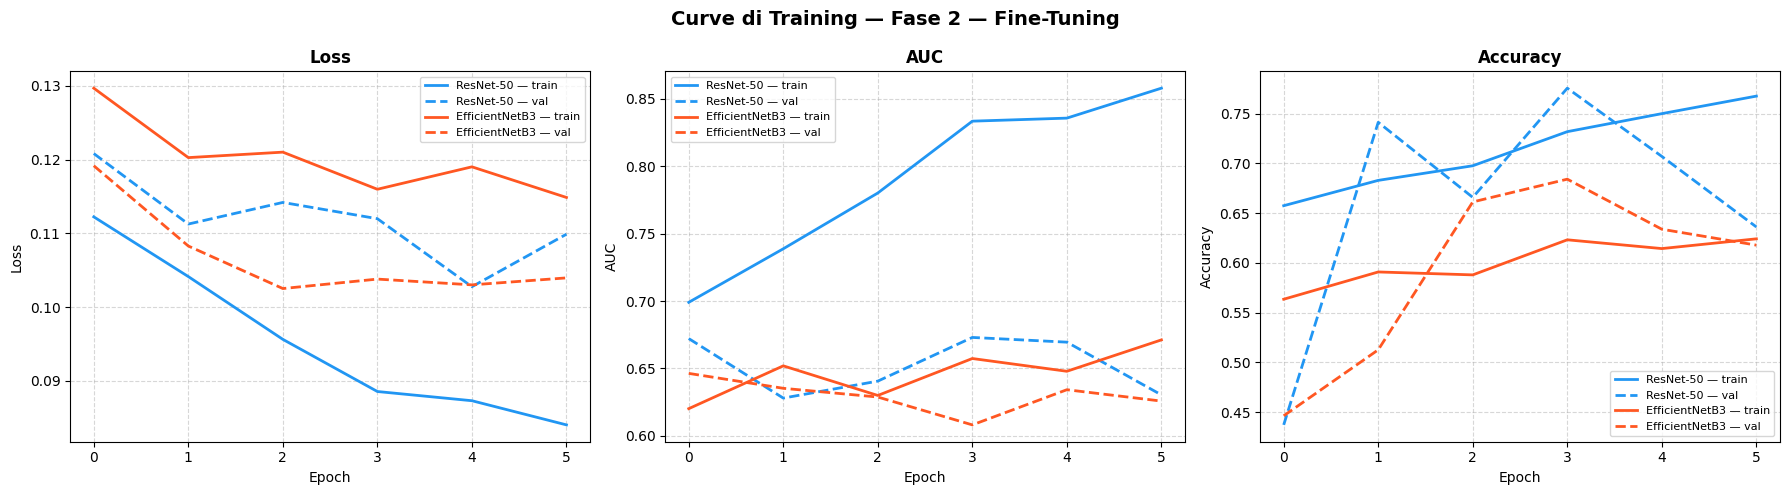

Grafico fase 2 salvato in: ../results/confronto_metriche_val_classificatori/figures/training_log_fase2.png


In [6]:
LOG_METRICS = [
    ("loss",     "val_loss",     "Loss"),
    ("auc",      "val_auc",      "AUC"),
    ("accuracy", "val_accuracy", "Accuracy"),
]

FASE_LABELS = {1: "Fase 1 — Custom Head", 2: "Fase 2 — Fine-Tuning"}

for fase, (log_a, log_b) in enumerate([(log_a1, log_b1), (log_a2, log_b2)], start=1):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Curve di Training — {FASE_LABELS[fase]}", fontsize=14, fontweight='bold')

    for ax, (train_col, val_col, metric_label) in zip(axes, LOG_METRICS):
        ax.plot(log_a["epoch"], log_a[train_col],
                color=MODEL_A["color"], linewidth=2, linestyle="-",
                label=f"{MODEL_A['label']} — train")
        ax.plot(log_a["epoch"], log_a[val_col],
                color=MODEL_A["color"], linewidth=2, linestyle="--",
                label=f"{MODEL_A['label']} — val")

        ax.plot(log_b["epoch"], log_b[train_col],
                color=MODEL_B["color"], linewidth=2, linestyle="-",
                label=f"{MODEL_B['label']} — train")
        ax.plot(log_b["epoch"], log_b[val_col],
                color=MODEL_B["color"], linewidth=2, linestyle="--",
                label=f"{MODEL_B['label']} — val")

        ax.set_title(metric_label, fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel(metric_label, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(linestyle="--", alpha=0.5)

    plt.tight_layout()
    log_fig_path = os.path.join(FIGURES_DIR, f"training_log_fase{fase}.png")
    fig.savefig(log_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Grafico fase {fase} salvato in: {log_fig_path}")